# Linear Regression — Theory and Practice
### Block 1 of Phase 1 · ML-Notes-and-Projects

This notebook is my study log for linear regression, combining the theoretical foundations from *An Introduction to Statistical Learning* (ISLP, Chapters 2-3) with the hands-on implementation approach from *Hands-On Machine Learning* (HOML, Chapter 4).

Instead of using ISLP's synthetic example ($Y=2+3X+\varepsilon$), here I work with a real, public dataset: the **Ames Housing dataset** (De Cock, 2011), which contains 2930 residential property sales in Ames, Iowa, described by 82 features (numerical + categorical) plus the target variable SalePrice.

### Goals of this notebook
1. Understand and implement **Simple Linear Regression** from scratch (Normal Equation + Gradient Descent), then validate against "scikit-learn" and "statsmodels".
2. Extend to **Multiple Linear Regression**, including categorical predictors.
3. Understand and interpret **interferential statistics**: standar errors, the t-test for individual coefficients, the F-test for overall model significance, $R^2$/ adjusted $R^2$, and confidence intervals.
4. Check the **assumptions** behind the linear model (linearity, homoscedasticity, normality of residuals, multicollinearity).

### Dataset source
Ames Housing dataset, originally compiled by Dean De Cock as a modern, ethically-sourced alternative to the Boston Housing dataset. Source CSV: https://github.com/wblakecannon/ams (mirrors the original data relased for the Kaggle House Prices competition, unsplit).

# 0. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

np.random.seed(42)

# 1. First Look at the Data

In [3]:
df = pd.read_csv("housing.csv")
print(df.shape)
df.head()

(2930, 83)


,Unnamed: 0,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 83 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       2930 non-null   int64  
 1   Order            2930 non-null   int64  
 2   PID              2930 non-null   int64  
 3   MS SubClass      2930 non-null   int64  
 4   MS Zoning        2930 non-null   object 
 5   Lot Frontage     2440 non-null   float64
 6   Lot Area         2930 non-null   int64  
 7   Street           2930 non-null   object 
 8   Alley            198 non-null    object 
 9   Lot Shape        2930 non-null   object 
 10  Land Contour     2930 non-null   object 
 11  Utilities        2930 non-null   object 
 12  Lot Config       2930 non-null   object 
 13  Land Slope       2930 non-null   object 
 14  Neighborhood     2930 non-null   object 
 15  Condition 1      2930 non-null   object 
 16  Condition 2      2930 non-null   object 
 17  Bldg Type     

We have 2930 observations and 82 columns (81 predictors + SalePrice). A quick check on the target variable and on missing values:

In [7]:
df["SalePrice"].describe()

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64

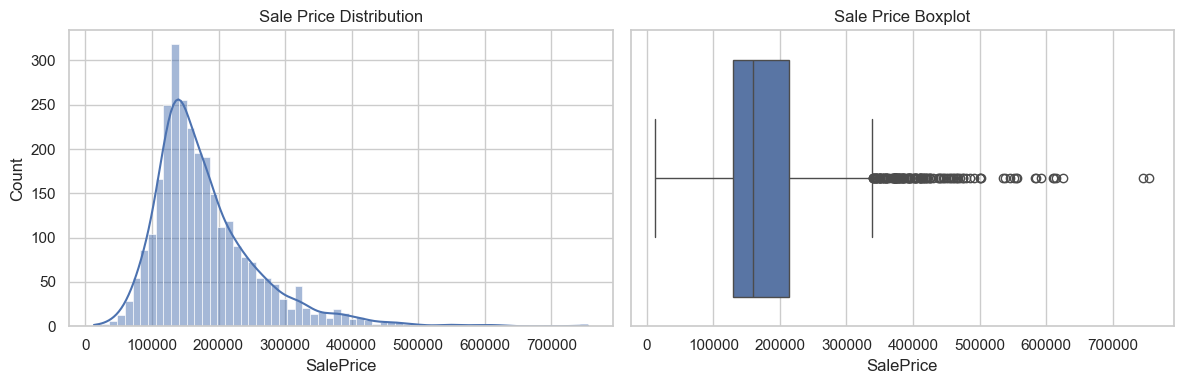

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["SalePrice"], kde=True, ax=axes[0])
axes[0].set_title("Sale Price Distribution")
sns.boxplot(x=df["SalePrice"], ax=axes[1])
axes[1].set_title("Sale Price Boxplot")
plt.tight_layout()
plt.show()

SalePrice is right-skewed, as is typical for price data (a handful of expensive houses pull the mean above the median). We'll keep this in mind: it can affect the normality of residuals later on, and is a common reason practitioners model $\log{(\text{SalePrice})}$ instead. For now we work with the raw scale to keep the coefficient interpretation intuitive, and revisit this in the residual diagnostics section.